In [94]:
import random
import re
from enum import Enum

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb


# =========================
# ZONES
# =========================

class Zone(Enum):
    RESIDENTIAL = "Residential"
    COMMERCIAL = "Commercial"
    HOSPITAL = "Hospital"
    SCHOOL = "School"
    INDUSTRIAL = "Industrial"
    OPEN_FIELD = "Open Field"


# =========================
# CELL
# =========================

class Cell:

    def __init__(
        self,
        row,
        col,
        zone,
        density=0,
        is_hub=False,
        is_charging=False,
        is_medical_pickup=False,
        demand=0
    ):

        self.row = row
        self.col = col

        self.zone = zone

        self.density = density

        self.is_hub = is_hub

        self.is_charging = is_charging

        self.is_medical_pickup = is_medical_pickup

        self.demand = demand

    def __str__(self):

        return f"({self.row}, {self.col}) {self.zone.value}"



In [95]:
# =========================
# GRID
# =========================

class Grid:

    def __init__(self, rows, cols, zone_limits=None):

        self.rows = rows
        self.cols = cols

        self.grid = []

        # Max cells per zone (non–Open Field). Any OPEN_FIELD entry is ignored;
        # remaining cells after quotas are filled with Open Field.
        self.zone_limits = zone_limits

    # -----------------------------------
    # RANDOM GRID GENERATION
    # -----------------------------------

    def populate_grid(self):

        self.grid = []

        total = self.rows * self.cols

        def make_cell(row, col, zone):

            return Cell(
                row=row,
                col=col,
                zone=zone,
                density=random.randint(0, 100),
                is_hub=random.choice([True, False]),
                is_charging=random.choice([True, False]),
                is_medical_pickup=random.choice([True, False]),
                demand=random.randint(0, 50),
            )

        if self.zone_limits is None:

            for row in range(self.rows):

                current_row = []

                for col in range(self.cols):

                    zone = random.choice(list(Zone))

                    current_row.append(make_cell(row, col, zone))

                self.grid.append(current_row)

            return

        caps = {}

        for z, n in self.zone_limits.items():

            if z == Zone.OPEN_FIELD:
                continue

            if n < 0:
                raise ValueError(
                    f"Zone limit for {z} must be non-negative, got {n}"
                )

            caps[z] = int(n)

        pool = []

        for z, cap in caps.items():
            pool.extend([z] * cap)

        if len(pool) > total:
            raise ValueError(
                f"Sum of zone limits ({len(pool)}) exceeds grid size ({total}). "
                "Lower the limits or enlarge the grid."
            )

        pool.extend([Zone.OPEN_FIELD] * (total - len(pool)))
        random.shuffle(pool)

        i = 0

        for row in range(self.rows):

            current_row = []

            for col in range(self.cols):

                current_row.append(make_cell(row, col, pool[i]))
                i += 1

            self.grid.append(current_row)

    # -----------------------------------
    # HELPERS
    # -----------------------------------

    def get_neighbors(self, row, col):

        neighbors = []

        directions = [
            (-1, 0),  # up
            (1, 0),   # down
            (0, -1),  # left
            (0, 1)    # right
        ]

        for dr, dc in directions:

            nr = row + dr
            nc = col + dc

            if 0 <= nr < self.rows and 0 <= nc < self.cols:

                neighbors.append(self.grid[nr][nc])

        return neighbors

    def manhattan(self, a, b):

        return abs(a.row - b.row) + abs(a.col - b.col)

    # -----------------------------------
    # R1
    # Industrial NOT adjacent to
    # School or Hospital
    # -----------------------------------

    def check_industrial_safety(self):

        errors = []

        for row in self.grid:

            for cell in row:

                if cell.zone == Zone.INDUSTRIAL:

                    neighbors = self.get_neighbors(cell.row, cell.col)

                    for n in neighbors:

                        if n.zone in [Zone.SCHOOL, Zone.HOSPITAL]:

                            errors.append(
                                f"R1 FAILED: Industrial cell "
                                f"({cell.row}, {cell.col}) adjacent to "
                                f"{n.zone.value} at ({n.row}, {n.col})"
                            )

        return errors

    # -----------------------------------
    # R2
    # Residential must be within
    # 3 cells of a hub
    # -----------------------------------

    def check_residential_coverage(self):

        errors = []

        hubs = []

        for row in self.grid:
            for cell in row:
                if cell.is_hub:
                    hubs.append(cell)

        for row in self.grid:

            for cell in row:

                if cell.zone == Zone.RESIDENTIAL:

                    covered = False

                    for hub in hubs:

                        if self.manhattan(cell, hub) <= 3:

                            covered = True
                            break

                    if not covered:

                        errors.append(
                            f"R2 FAILED: Residential cell "
                            f"({cell.row}, {cell.col}) "
                            f"is farther than 3 cells from every hub"
                        )

        return errors

    # -----------------------------------
    # R3
    # Every hub needs charging
    # within 2 cells
    # -----------------------------------

    def check_hub_charging(self):

        errors = []

        charging_cells = []

        for row in self.grid:
            for cell in row:
                if cell.is_charging:
                    charging_cells.append(cell)

        for row in self.grid:

            for cell in row:

                if cell.is_hub:

                    valid = False

                    for charging in charging_cells:

                        if self.manhattan(cell, charging) <= 2:

                            valid = True
                            break

                    if not valid:

                        errors.append(
                            f"R3 FAILED: Hub at "
                            f"({cell.row}, {cell.col}) "
                            f"has no charging pad within 2 cells"
                        )

        return errors

    # -----------------------------------
    # R4
    # At least one hospital must
    # have medical pickup within 1 cell
    # -----------------------------------

    def check_medical_access(self):

        hospitals = []

        pickups = []

        for row in self.grid:
            for cell in row:

                if cell.zone == Zone.HOSPITAL:
                    hospitals.append(cell)

                if cell.is_medical_pickup:
                    pickups.append(cell)

        for hospital in hospitals:

            for pickup in pickups:

                if self.manhattan(hospital, pickup) <= 1:

                    return []

        return [
            "R4 FAILED: No hospital has a medical pickup point within 1 cell"
        ]

    # -----------------------------------
    # VALIDATE ALL
    # -----------------------------------

    def validate(self):

        errors = []

        errors.extend(self.check_industrial_safety())

        errors.extend(self.check_residential_coverage())

        errors.extend(self.check_hub_charging())

        errors.extend(self.check_medical_access())

        return errors

    # -----------------------------------
    # SELF-REPAIR FROM VALIDATION ERRORS
    # -----------------------------------

    _R1_INDUSTRY = re.compile(
        r"Industrial cell \((\d+), (\d+)\) adjacent to"
    )
    _R2_RESIDENTIAL = re.compile(
        r"Residential cell \((\d+), (\d+)\)"
    )
    _R3_HUB = re.compile(
        r"Hub at \((\d+), (\d+)\)"
    )

    def fix_from_errors(self, errors):

        changed = False

        for err in errors:

            if err.startswith("R1 FAILED"):
                m = self._R1_INDUSTRY.search(err)
                if not m:
                    continue
                r, c = int(m.group(1)), int(m.group(2))
                cell = self.grid[r][c]
                if cell.zone == Zone.INDUSTRIAL:
                    cell.zone = random.choice(
                        [Zone.OPEN_FIELD, Zone.COMMERCIAL]
                    )
                    changed = True

            elif err.startswith("R2 FAILED"):
                m = self._R2_RESIDENTIAL.search(err)
                if not m:
                    continue
                r, c = int(m.group(1)), int(m.group(2))
                placed = False
                for dr in range(-3, 4):
                    for dc in range(-3, 4):
                        if abs(dr) + abs(dc) > 3:
                            continue
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < self.rows and 0 <= nc < self.cols:
                            self.grid[nr][nc].is_hub = True
                            placed = True
                            break
                    if placed:
                        break
                if placed:
                    changed = True

            elif err.startswith("R3 FAILED"):
                m = self._R3_HUB.search(err)
                if not m:
                    continue
                r, c = int(m.group(1)), int(m.group(2))
                self.grid[r][c].is_charging = True
                changed = True

            elif err.startswith("R4 FAILED"):
                fixed_r4 = False
                for row in self.grid:
                    for cell in row:
                        if cell.zone == Zone.HOSPITAL:
                            cell.is_medical_pickup = True
                            changed = True
                            fixed_r4 = True
                            break
                    if fixed_r4:
                        break
                if not fixed_r4:
                    c0 = self.grid[0][0]
                    c0.zone = Zone.HOSPITAL
                    c0.is_medical_pickup = True
                    changed = True

        return changed

    def repair(self, max_iterations=200):

        for _ in range(max_iterations):
            errors = self.validate()
            if not errors:
                return True
            if not self.fix_from_errors(errors):
                break

        return len(self.validate()) == 0

    # -----------------------------------
    # REPORT
    # -----------------------------------

    def print_report(self):

        errors = self.validate()

        print("\n==============================")
        print(" AERONET LAYOUT VALIDATION ")
        print("==============================\n")

        if len(errors) == 0:

            print("Layout validity = TRUE")
            print("All CSP constraints satisfied.")

        else:

            print("Layout validity = FALSE\n")

            for error in errors:
                print(error)

    def display_grid(self, figsize=None, ax=None, title="Zone layout"):

        zone_colors = {
            Zone.RESIDENTIAL: "#DEB887",
            Zone.COMMERCIAL: "#5B8DEE",
            Zone.HOSPITAL: "#E85D75",
            Zone.SCHOOL: "#F2C94C",
            Zone.INDUSTRIAL: "#5C6670",
            Zone.OPEN_FIELD: "#59A14F",
        }

        rgb = [
            [to_rgb(zone_colors[cell.zone]) for cell in row]
            for row in self.grid
        ]

        created_fig = ax is None
        if created_fig:
            if figsize is None:
                figsize = (max(6.0, self.cols * 0.55), max(5.0, self.rows * 0.55))
            _, ax = plt.subplots(figsize=figsize)

        ax.imshow(rgb, origin="upper", aspect="equal", interpolation="nearest")
        ax.set_title(title)
        ax.set_xticks([i - 0.5 for i in range(self.cols + 1)], minor=True)
        ax.set_yticks([i - 0.5 for i in range(self.rows + 1)], minor=True)
        ax.grid(which="minor", color="white", linewidth=0.8)
        ax.tick_params(
            which="both",
            bottom=False,
            left=False,
            labelbottom=False,
            labelleft=False,
        )

        handles = [
            mpatches.Patch(color=zone_colors[z], label=z.value) for z in Zone
        ]
        ax.legend(
            handles=handles,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.06),
            ncol=3,
            fontsize=9,
            frameon=False,
        )

        if created_fig:
            fig = ax.figure
            fig.tight_layout()
            fig.subplots_adjust(bottom=0.18)
            try:
                __IPYTHON__  # noqa: F821
                plt.show()
            except NameError:
                if matplotlib.is_interactive():
                    plt.show()
                else:
                    plt.close(fig)

        return ax



 AERONET LAYOUT VALIDATION 

Layout validity = FALSE

R1 FAILED: Industrial cell (1, 4) adjacent to School at (1, 3)
R1 FAILED: Industrial cell (5, 3) adjacent to Hospital at (5, 4)
R1 FAILED: Industrial cell (7, 3) adjacent to School at (7, 2)

 AERONET LAYOUT VALIDATION 

Layout validity = TRUE
All CSP constraints satisfied.


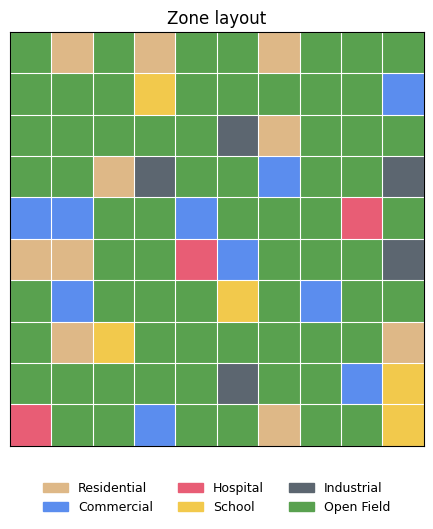

<Axes: title={'center': 'Zone layout'}>

In [96]:
# =========================
# RUN
# =========================

# zone_limits: max cells per zone (excluding Open Field). Unlisted zones = 0.
# Remaining cells are Open Field. Ignore any Zone.OPEN_FIELD key.
grid = Grid(
    10,
    10,
    zone_limits={
        Zone.RESIDENTIAL: 10,
        Zone.COMMERCIAL: 10,
        Zone.HOSPITAL: 3,
        Zone.SCHOOL: 5,
        Zone.INDUSTRIAL: 8,
    },
)

grid.populate_grid()

# Auto-fix using the same error strings produced by validate()
grid.print_report()
grid.repair()

grid.print_report()
grid.display_grid()